In [1]:
import lamindb as ln
from napari_spatialdata import Interactive  # noqa: F401
import spatialdata as sd
import spatialdata_plot
import easy_vitessce
from spatialdata._io.format import RasterFormatV02, SpatialDataContainerFormatV01

→ connected lamindb: scverse/spatialdata-db


/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
# we will download the dataset "Xenium FFPE Healthy Human Breast", provided from 10x Genomics https://www.10xgenomics.com/datasets/ffpe-human-breast-with-custom-add-on-panel-1-standard
#
# spatialdata-db link:
# https://lamin.ai/scverse/spatialdata-db/artifacts?filter[and][0][or][0][is_latest][eq]=true&filter[and][1][or][0][branch.name][eq]=main&filter[and][2][or][0][schema.name][eq]=Xenium
artifact = ln.Artifact.get("Uj7J4jjgzHw0lcm80001")
gb = artifact.size / 1_000_000_000
print(f"{gb:.2f} GB")

7.23 GB


In [3]:
print(artifact.description)

Xenium FFPE Healthy Human Breast (Tissue sample 2, Custom Panel)


In [4]:
artifact.cache()
f = artifact._cache_path

! run input wasn't tracked, call `ln.track()` and re-run


In [5]:
sdata = sd.read_zarr(str(f))
print(sdata)

/tmp/ipykernel_78322/2598112575.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(str(f))
no parent found for <ome_zarr.reader.Label object at 0x34519f800>: None
no parent found for <ome_zarr.reader.Label object at 0x3451f3320>: None


SpatialData object, with associated Zarr store: /Users/macbook/Library/Caches/lamindb/scverse-spatial-eu-central-1/10pf0.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 41411, 45749), (1, 20705, 22874), (1, 10352, 11437), (1, 5176, 5718), (1, 2588, 2859)
│     ├── 'morphology_focus_scale3': DataArray[cyx] (1, 5176, 5718)
│     └── 'morphology_mip': DataTree[cyx] (1, 41411, 45749), (1, 20705, 22874), (1, 10352, 11437), (1, 5176, 5718), (1, 2588, 2859)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (41411, 45749), (20705, 22874), (10352, 11437), (5176, 5718), (2588, 2859)
│     └── 'nucleus_labels': DataTree[yx] (41411, 45749), (20705, 22874), (10352, 11437), (5176, 5718), (2588, 2859)
├── Points
│     └── 'transcripts': DataFrame with shape: (<dask_expr.expr.Scalar: expr=ReadParquetFSSpec(323d9ab).size() // 8, dtype=int64>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (365604, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (3

/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/zarr/core/group.py:3530: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [6]:
# there is a problem in rending the multiscale image in easy-vitessce
sdata.pl.render_shapes('cell_circles', color='ABCC11').pl.show()

Deactivated Vitessce spatialdata-plot
INFO     Rasterizing image for faster rendering.                                                                   


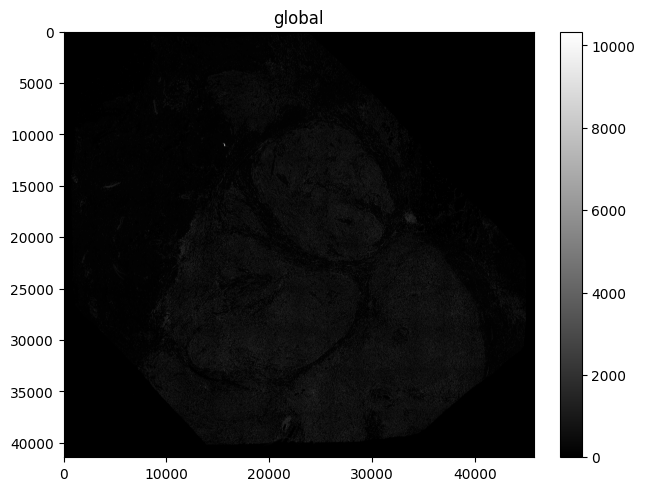

In [13]:
easy_vitessce.configure_plots(disable_plots = ["spatialdata-plot"])
sdata.pl.render_images('morphology_mip', cmap='gray').pl.show()
easy_vitessce.configure_plots(enable_plots = ["spatialdata-plot"])

In [8]:
# Interactive(sdata)